(cc_ramp_pt1)=
# Current clamp ramp : Part 1
We will cover how to analyze ramp current injections in this chapter.

In [1]:
import json
import urllib
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bokeh.io import output_notebook, show
from bokeh.layouts import column, gridplot, row
from bokeh.models import ColumnDataSource, CustomJS, Slider, Spinner
from bokeh.plotting import figure
from scipy import optimize, signal, stats

output_notebook()

Loading BokehJS ...

First we are going to load our data and define our analysis variables.

In [2]:
temp_path = cwd = Path.cwd().parent/"data/ramp"
exp_dict = {}
for index in range(135, 139):
    with open(temp_path/ f"{index}.json", "r") as rf:
        temp = json.load(rf)
        temp["array"] = np.array(temp["array"])
        exp_dict[index] = temp
x_array = np.arange(len(exp_dict[index]["array"])) / 10

In [3]:
start = 3000
end = 40000
fs = 10000
pulse_amp = 300

The first thing to do is look through your data just to see what it looks like. For reference the data in this tutorial is from MSN in the DMS of an adult mouse. 
- The recorded data is usually in mV, as is the case for this data.
- There is a short baseline of about 300 ms before the current injection starts.
- There is a ramp current injection that starts a 0 pA and goes up to 300 pA.
- There is a point where the cell will spike.
- There are 4 repeates or sweeps.
- The voltage the cell shows before the spiking occurs is nonlinear. This is important because resistance is not linear even though our analysis makes the assumption that it is. With the ramp current injection this becomes very clear. Not all cells show as strong a nonlinear change in voltage as MSNs. Some cells like PV interneurons do not spike with slow ramp current injections due to depolarization block.

In [ ]:
# Initial data
source = ColumnDataSource(data={"x": x_array, "y": exp_dict[1]["array"]})

# Create a plot
plot = figure(
    x_axis_label="Time (ms)", y_axis_label="Voltage (mV)", width=400, height=300
)
plot.line("x", "y", source=source, line_color="black")
spinner = Spinner(title="Acquisition", low=135, high=138, step=1, value=1, width=80)

# JavaScript callback to fetch JSON data and update plot
callback = CustomJS(
    args=dict(source=source, spinner=spinner),
    code="""
    let val = spinner.value
    let URL = `https://cdn.jsdelivr.net/gh/LarsHenrikNelson/PatchClampHandbook@main/data/current_clamp/${val}.json`
    fetch(URL)
    .then(response => response.json())
    .then(data => {
        source.data.y = data["array"];
        source.change.emit();
    })
    .catch(error => console.error('Error fetching data:', error));
""",
)

# Add a button to trigger the callback
spinner.js_on_change("value", callback)

# Layout and show
layout = column(spinner, plot)
show(layout)

To begin analyzing the data we should first create a ramp pulse. Many papers will define the ramp by the start current injection which is usually 0 up to the final current injection and then how fast the current injection occurs.

Ramp rate: 81.08108108108108 pA/s


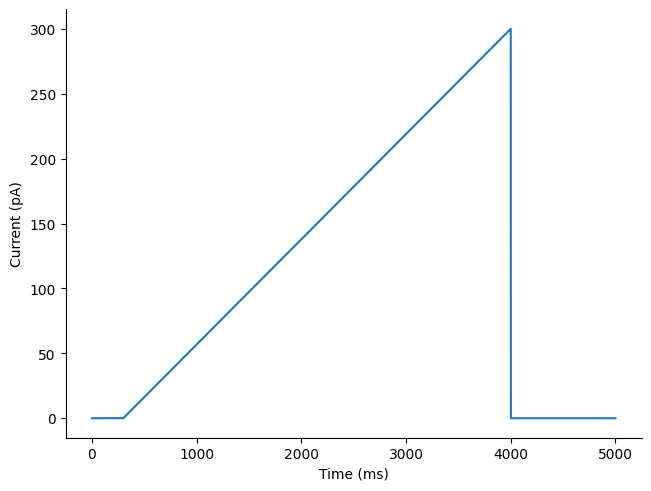

In [23]:
ramp = np.zeros(x_array.size)
ramp[start:end] = np.linspace(0, 300, num=int(end-start))
fig, ax = plt.subplots(layout="constrained")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Current (pA)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
print(f"Ramp rate: {300/((40000-3000)/10000)} pA/s")
_ = ax.plot(x_array, ramp)

We can do a similar analysis as in [Current clamp square pulse: Part 1](cc_pt1) to find peaks and the spike threshold. However, for this analysis we are going to focus on analyzing the first spikes only so that we can get rheobase and the membrane resistance. However, to find rheobase we will need to find the spike threshold.

# Finding spike threshold
We can use a similar method, the third derivative to find the spike threshold as we did in the square pulse chapter. First we find the peaks then use that to find the first spike threshold.

In [30]:
for value in exp_dict.values():
    array = value["array"]
    peaks, _ = signal.find_peaks(
        array,
        height=10,
        prominence=10,
    )

    value["first_peak"] = peaks[0]
    value["second_peak"] = peaks[1]
    first = np.gradient(array)
    second = np.gradient(first)
    third = np.gradient(second)
    value["threshold"] = np.argmax(third[start:peaks[0]])+start

First we should check to make sure our spike threshold looks good.

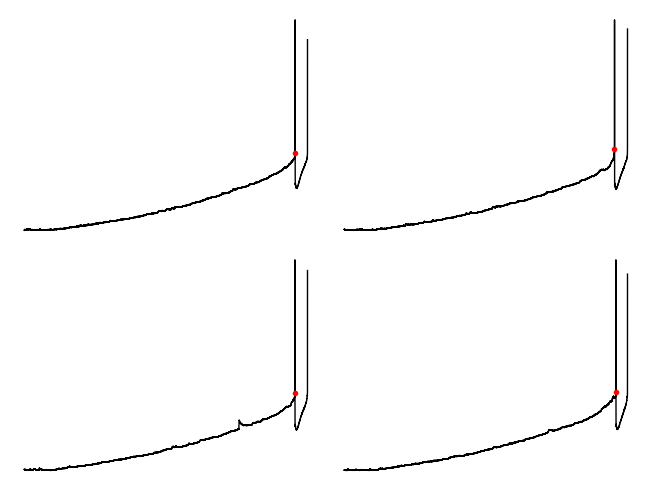

In [56]:
fig, axes = plt.subplots(nrows=2, ncols=2, layout="constrained")
for acq, ax in zip(exp_dict.values(), axes.flat):
    threshold = acq["threshold"]
    ax.plot(
        x_array[: acq["second_peak"]],
        acq["array"][: acq["second_peak"]],
        color="black",
        linewidth=1,
    )
    ax.plot(x_array[threshold], acq["array"][threshold], ".", color="red", linewidth=1)
    ax.axis("off")

Next we can calculate rheobase. For ramp current injections, rheobase is the current at which the spike threshold occurs.

In [28]:
rheobase = np.mean([ramp[i["threshold"]] for i in exp_dict.values()])
print(f"Rheobase: {rheobase} pA")

Rheobase: 212.60642179518365 pA


Next we will plot the current vs the $\delta V$. To calculate $\delta V$ we can baseline the acquisition by subtracting the mean of the baseline or by subtracting the minimum value. One important thing is that membrane resistance becomes nonlinear as the neuron gets close to the spike threshold. Another thing is that in this MSN, the membrane resistance increases linearly as we get farther from the baseline membrane voltage. I removed the first 10 ms of the instaneous membrane resistance because there is a lot of noise.

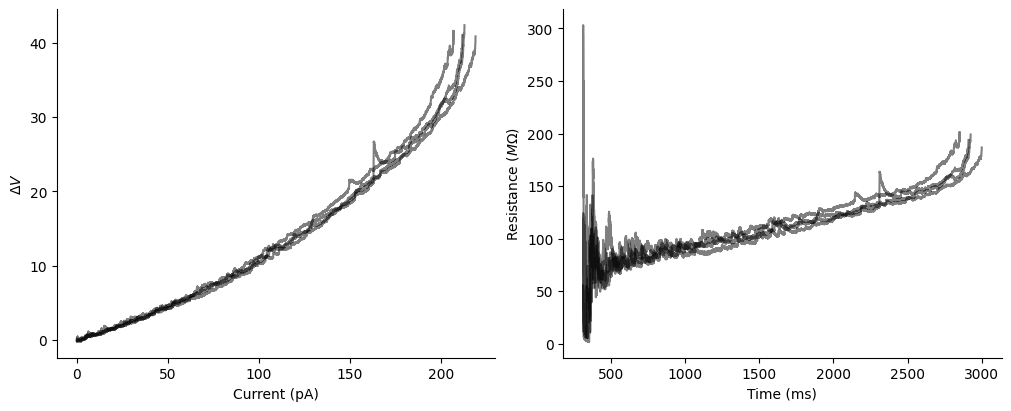

In [70]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 4), layout="constrained")
for acq in exp_dict.values():
    threshold = acq["threshold"]
    temp = acq["array"] - acq["array"][:3000].mean()
    indexes = (
        np.where(
            (temp[start + 100 : threshold] > 0) & (ramp[start + 100 : threshold] > 0)
        )[0]
        + start
        + 100
    )
    resistance = temp[indexes] / ramp[indexes] * 1000
    ax[0].plot(ramp[start:threshold], temp[start:threshold], color="black", alpha=0.5)
    ax[0].set_xlabel("Current (pA)")
    ax[0].set_ylabel(r"$\Delta V$")
    ax[1].plot(indexes / 10, resistance, color="black", alpha=0.5)
    ax[1].set_xlabel("Time (ms)")
    ax[1].set_ylabel(r"Resistance ($M\Omega$)")
    for i in ax:
        i.spines["top"].set_visible(False)
        i.spines["right"].set_visible(False)

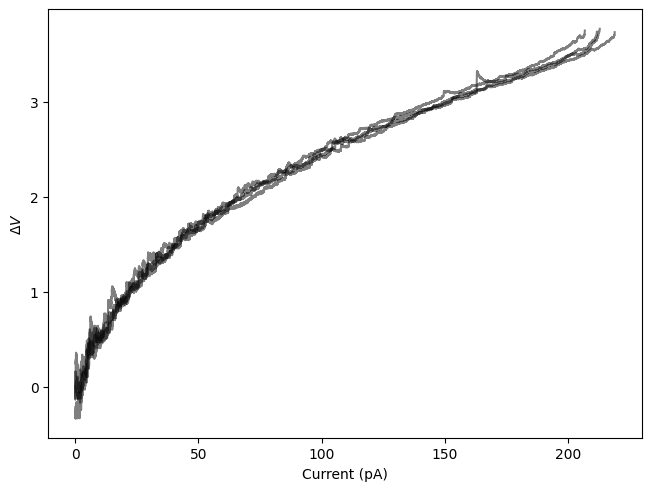

In [64]:
fig, ax = plt.subplots(layout="constrained")
for acq in exp_dict.values():
    threshold = acq["threshold"]
    temp = acq["array"] - acq["array"][:3000].mean()
    ax.plot(ramp[start:threshold], np.log1p(temp[start:threshold]), color="black", alpha=0.5)
    ax.set_xlabel("Current (pA)")
    ax.set_ylabel(r"$\Delta V$")
    i.spines["top"].set_visible(False)
    i.spines["right"].set_visible(False)